In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

from google.colab import files

print("Setup Complete")

uploaded = files.upload()

zip_name = next(iter(uploaded))

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('fars2023')

print("Fars 2023 files extracted successfully.")

Setup Complete


Saving FARS2023NationalCSV.zip to FARS2023NationalCSV (1).zip
Fars 2023 files extracted successfully.


In [5]:
import os

# Load FARS 2023 datasets

# It's common for zip files to extract into a subfolder. Let's check the contents of 'fars2023'.
# Assuming the extracted folder is named 'FARS2023NationalCSV' based on the zip file name.
# To verify, you could run: os.listdir('fars2023') and then os.listdir('fars2023/<subfolder_name>')

base_path = 'fars2023/FARS2023NationalCSV'

accident = pd.read_csv(f'{base_path}/accident.csv')
person = pd.read_csv(f'{base_path}/person.csv')
vehicle = pd.read_csv(f'{base_path}/vehicle.csv')

print("ACCIDENT:", accident.shape)
print("PERSON:", person.shape)
print("VEHICLE:", vehicle.shape)

/tmp/ipykernel_1908/2449318613.py:13: DtypeWarning: Columns (54,64,68) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicle = pd.read_csv(f'{base_path}/vehicle.csv')


ACCIDENT: (37769, 80)
PERSON: (92768, 126)
VEHICLE: (58508, 203)


In [6]:
# Create study population and binary injury-severity outcome

occupants = person.loc[
    person['PER_TYP'].isin([1, 2])
].copy()

analysis_clean = occupants.loc[
    occupants['INJ_SEV'].isin([0, 1, 2, 3,4])
].copy()

analysis_clean['SEVERE_INJURY'] = (analysis_clean['INJ_SEV'].isin([3, 4])
).astype(int)

print("Occupants:", occupants.shape)
print("Final injury-severity sample:", analysis_clean.shape)
print("\nOutcome distribution:")
print(analysis_clean['SEVERE_INJURY'].value_counts())


Occupants: (82893, 126)
Final injury-severity sample: (81269, 127)

Outcome distribution:
SEVERE_INJURY
1    41361
0    39908
Name: count, dtype: int64


In [19]:
# Add accident-level variables

accident_context = accident[
    ['ST_CASE', 'RUR_URB', 'LGT_COND', 'WEATHER']
].copy()

analysis_clean = analysis_clean.merge(
    accident_context,
    on='ST_CASE',
    how='left',
)

# Urban/Rural
analysis_clean['URBAN'] = analysis_clean['RUR_URB'].map({
    1: 0,
    2: 1
})

# Lighting
analysis_clean['DARK'] = analysis_clean['LGT_COND'].map({
    1: 0,
    2: 1,
    3: 1,
    4: 1
})

# Weather
analysis_clean['ADVERSE_WEATHER'] = analysis_clean['WEATHER'].map({
    1: 0,   # Clear
    2: 1,   # Rain
    3: 1,   # Sleet/Hail
    4: 1,   # Snow
    5: 1,   # Fog/Smoke/Smog
    6: 1,   # Severe Crosswinds
    7: 1,   # Blowing Sand/Soil/Dart
    10: 1,  # Cloudy
    11: 1,  # Blowing Snow
    12: 1   # Freezing Rain/Drizzle
})

print("analysis_shape:", analysis_clean.shape)
print("\nUrban:")
print(analysis_clean['URBAN'].value_counts(dropna=False))
print("\nDark:")
print(analysis_clean['DARK'].value_counts(dropna=False))
print("\nAdverse Weather:")
print(analysis_clean['ADVERSE_WEATHER'].value_counts(dropna=False))

KeyError: 'RUR_URB'

In [21]:
# Check whether each ST_CASE appears only once in accident data

print("Total accident rows:", len(accident))
print("Unique ST_CASE rows:", accident['ST_CASE'].nunique())
print("Duplicate ST_CASE rows:", accident.duplicated(subset=['ST_CASE']).sum())

Total accident rows: 37769
Unique ST_CASE rows: 37769
Duplicate ST_CASE rows: 0


In [22]:
# ============================================
# Step 6: Accident-Level Safety Variables
# ============================================

accident_context = accident[
    ['ST_CASE', 'RUR_URB', 'LGT_COND', 'WEATHER']
].copy()

analysis_clean = analysis_clean.merge(
    accident_context,
    on='ST_CASE',
    how='left',
    validate= 'many_to_one'
)

# Urban / Rural
# 0 = Rural, 1 = Urban
analysis_clean['URBAN'] = analysis_clean['RUR_URB'].map({
    1: 0,
    2: 1
})

# Lighting
# 0 = Daylight, 1 = Dark
analysis_clean['DARK'] = analysis_clean['LGT_COND'].map({
    1: 0,
    2: 1,
    3: 1,
    4: 1
})

# Weather
# 0 = Clear, 1 = Adverse/other reported weather conditions
analysis_clean['ADVERSE_WEATHER'] = analysis_clean['WEATHER'].map({
    1: 0,
    2: 1,
    3: 1,
    4: 1,
    5: 1,
    6: 1,
    7: 1,
    10: 1,
    11: 1,
    12: 1
})

print("Analysis_shape:", analysis_clean.shape)

print("\nUrban")
print(analysis_clean['URBAN'].value_counts(dropna=False))
print("\nDark")
print(analysis_clean['DARK'].value_counts(dropna=False))
print("\nAdverse Weather")
print(analysis_clean['ADVERSE_WEATHER'].value_counts(dropna=False))

Analysis_shape: (81269, 138)

Urban
URBAN
1.0    47848
0.0    33140
NaN      281
Name: count, dtype: int64

Dark
DARK
0.0    39847
1.0    38163
NaN     3259
Name: count, dtype: int64

Adverse Weather
ADVERSE_WEATHER
0.0    60530
1.0    18204
NaN     2535
Name: count, dtype: int64


In [26]:
# Add intersection variable to the existing analysis dataset

intersection_context = accident[['ST_CASE', 'TYP_INT']].copy()

analysis_clean = analysis_clean.merge(
    intersection_context,
    on='ST_CASE',
    how='left',
    validate= 'many_to_one'
)

print("TYP_INT value counts:")
print(analysis_clean['TYP_INT'].value_counts(dropna=False).sort_index())

TYP_INT value counts:


KeyError: 'TYP_INT'

In [27]:
print("Columns containing 'TYP' or 'INT':")
print([
    col for col in accident.columns
    if 'TYP' in col.upper() or 'INT' in col.upper()
])

Columns containing 'TYP' or 'INT':
['TYP_INT', 'TYP_INTNAME']


In [28]:
# Add TYP_INT to analysis_clean

analysis_clean = analysis_clean.drop(
    columns=['TYP_INT'],
    errors = 'ignore'
)

analysis_clean = analysis_clean.merge(
    intersection_context,
    on='ST_CASE',
    how='left',
    validate= 'many_to_one'
)

print("TYP_INT successfully addesd:", 'TYP_INT' in analysis_clean.columns)
print("\nTYP_INT value counts:")
print(
    analysis_clean['TYP_INT'].value_counts(dropna=False).sort_index()
)

TYP_INT successfully addesd: True

TYP_INT value counts:
TYP_INT
1     56489
2     16193
3      7614
4       398
5        18
6        73
7       127
10       48
11       38
98      260
99       11
Name: count, dtype: int64


In [29]:
# ===========================================
# STEP 7: Create Intersection Variable
# ===========================================

analysis_clean['INTERSECTION'] = analysis_clean['TYP_INT'].map({
    1: 0,
    2: 1,
    3: 1,
    4: 1,
    5: 1,
    6: 1,
    7: 1,
    10: 1,
    11: 1
})

print("INTERSECTION value counts:")
print(analysis_clean['INTERSECTION'].value_counts(dropna=False).sort_index()
)

INTERSECTION value counts:
INTERSECTION
0.0    56489
1.0    24509
NaN      271
Name: count, dtype: int64


In [30]:
# ==============================================
# STEP 8: Inspect Functional Class
# ==============================================

analysis_clean = analysis_clean.drop(
    columns=['FUNC_SYS'],
    errors = 'ignore'
)

analysis_clean = analysis_clean.merge(
    accident[['ST_CASE', 'FUNC_SYS']],
    on='ST_CASE',
    how='left',
    validate= 'many_to_one'
)

print("FUNC_SYS successfully added:", 'FUNC_SYS'in analysis_clean.columns)
print("\nFUNC_SYS value counts:")
print(analysis_clean['FUNC_SYS'].value_counts(dropna=False).sort_index())

FUNC_SYS successfully added: True

FUNC_SYS value counts:
FUNC_SYS
1     11539
2      3496
3     26147
4     18844
5     12142
6      2083
7      6591
96      215
98      194
99       18
Name: count, dtype: int64


In [31]:
print(
accident[['FUNC_SYS']].drop_duplicates().sort_values(by='FUNC_SYS')
)

     FUNC_SYS
4           1
25          2
8           3
11          4
0           5
32          6
1           7
189        96
949        98
947        99


In [32]:
# ===========================================
# STEP 9: Clean Functional Class
# ===========================================

analysis_clean['FUNCTIONAL_CLASS'] = analysis_clean['FUNC_SYS'].replace({
    96: np.nan,
    98: np.nan,
    99: np.nan
})

print("FUNCTIONAL_CLASS value counts:")
print(
    analysis_clean['FUNCTIONAL_CLASS'].value_counts(dropna=False).sort_index())

FUNCTIONAL_CLASS value counts:
FUNCTIONAL_CLASS
1.0    11539
2.0     3496
3.0    26147
4.0    18844
5.0    12142
6.0     2083
7.0     6591
NaN      427
Name: count, dtype: int64


In [33]:
# ===========================================
# STEP 10: Inspect Crush Hour
#============================================

analysis_clean = analysis_clean.drop(
    columns=['HOUR'],
    errors = 'ignore'
)

analysis_clean = analysis_clean.merge(
    accident[['ST_CASE', 'HOUR']],
    on='ST_CASE',
    how='left',
    validate= 'many_to_one'
)

print("HOUR successfully added:", 'HOUR' in analysis_clean.columns)
print("\nHOUR value counts:")
print(analysis_clean['HOUR'].value_counts(dropna=False).sort_index())

HOUR successfully added: True

HOUR value counts:
HOUR
0     2775
1     2581
2     2829
3     2176
4     1882
5     2393
6     2638
7     2444
8     2301
9     2169
10    2509
11    2704
12    3327
13    3439
14    4174
15    4441
16    4440
17    5051
18    4993
19    4746
20    4977
21    4647
22    3985
23    3349
99     299
Name: count, dtype: int64


In [34]:
# =============================================
# STEP 11: Create Time-of-day Variable
# =============================================

analysis_clean['TIME_period'] = pd.cut(
analysis_clean['HOUR'].replace(99, np.nan),
    bins=[-1, 5, 11, 17, 23],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
)

print("TIME_period value counts:")
print(analysis_clean['TIME_period'].value_counts(dropna=False))

TIME_period value counts:
TIME_period
Evening      26697
Afternoon    24872
Morning      14765
Night        14636
NaN            299
Name: count, dtype: int64


In [39]:
# ===========================================
#  STEP 12: Load Vehicle Data
# ===========================================

vehicle = pd.read_csv('fars2023/FARS2023NationalCSV/vehicle.csv')

print("Vehicle shape:", vehicle.shape)
print("\nFirst 30 columns:")
print(vehicle.columns[:30].tolist())

/tmp/ipykernel_1908/2430057923.py:5: DtypeWarning: Columns (54,64,68) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicle = pd.read_csv('fars2023/FARS2023NationalCSV/vehicle.csv')


Vehicle shape: (58508, 203)

First 30 columns:
['STATE', 'STATENAME', 'ST_CASE', 'VEH_NO', 'VE_FORMS', 'MONTH', 'MONTHNAME', 'DAY', 'DAYNAME', 'HOUR', 'HOURNAME', 'MINUTE', 'MINUTENAME', 'HARM_EV', 'HARM_EVNAME', 'MAN_COLL', 'MAN_COLLNAME', 'NUMOCCS', 'NUMOCCSNAME', 'UNITTYPE', 'UNITTYPENAME', 'HIT_RUN', 'HIT_RUNNAME', 'REG_STAT', 'REG_STATNAME', 'OWNER', 'OWNERNAME', 'VIN', 'VINNAME', 'MOD_YEAR']


In [40]:
# ===========================================
# STEP 13: Inspect Key Vehicle Variables
# ===========================================

vehicle_vars = [
    'ST_CASE', 'VEH_NO', 'BODY_TYP', 'BODY_TYPNAME', 'SPEEDREL', 'SPEEDRELNAME', 'TRAV_SP', 'TRAV_SPNAME', 'VTRAFWAY', 'VTRAFWAYNAME', 'M_HARM', 'M_HARMNAME', 'HIT_RUN', 'HIT_RUNNAME', 'MAN_COLL', 'MAN_COLLNAME']

print(vehicle[vehicle_vars].head)

<bound method NDFrame.head of        ST_CASE  VEH_NO  BODY_TYP  \
0        10001       1        14   
1        10002       1         5   
2        10003       1         4   
3        10004       1         6   
4        10005       1         4   
...        ...     ...       ...   
58503   560118       1        14   
58504   560119       1        66   
58505   560120       1        14   
58506   560120       2        67   
58507   560121       1        66   

                                            BODY_TYPNAME  SPEEDREL  \
0      Compact Utility (Utility Vehicle Categories "S...         0   
1                                5-door/4-door hatchback         0   
2                                  4-door sedan, hardtop         3   
3          Station Wagon (excluding van and truck based)         3   
4                                  4-door sedan, hardtop         4   
...                                                  ...       ...   
58503  Compact Utility (Utility Vehicle Categor

In [41]:
print("\nVehicle variables:")
print(vehicle[vehicle_vars].notna().sum())


Vehicle variables:
ST_CASE         58508
VEH_NO          58508
BODY_TYP        58508
BODY_TYPNAME    58508
SPEEDREL        58508
SPEEDRELNAME    58508
TRAV_SP         58508
TRAV_SPNAME     58508
VTRAFWAY        58508
VTRAFWAYNAME    58508
M_HARM          58508
M_HARMNAME      58508
HIT_RUN         58508
HIT_RUNNAME     58508
MAN_COLL        58508
MAN_COLLNAME    58508
dtype: int64


In [43]:
# ==========================================
# STEP 14: Inspect Vehicle Variable Distributions
# ==========================================

for col in[
    'BODY_TYP', 'SPEEDREL', 'TRAV_SP', 'VTRAFWAY', 'M_HARM', 'HIT_RUN', 'MAN_COLL'
]:
    print(f"\n===== {col} =====")
    print(vehicle[col].value_counts(dropna=False).head(20))



===== BODY_TYP =====
BODY_TYP
4     14681
34     9388
14     8672
80     5817
15     3155
66     3086
6      2339
2      1586
20     1334
5      1223
99     1000
63      688
67      631
21      622
61      610
3       468
1       419
62      321
84      260
98      255
Name: count, dtype: int64

===== SPEEDREL =====
SPEEDREL
0    43971
4     4555
3     4115
9     3313
5     2043
8      366
2      145
Name: count, dtype: int64

===== TRAV_SP =====
TRAV_SP
998    31357
999     4624
0       2483
55      2388
45      2061
60      1313
65      1251
70      1175
50      1165
40      1145
35      1053
10       661
30       656
15       583
80       486
25       440
5        431
20       419
75       404
100      294
Name: count, dtype: int64

===== VTRAFWAY =====
VTRAFWAY
1    30828
2    11203
3     8927
5     4304
6      926
4      835
0      628
8      468
7      372
9       17
Name: count, dtype: int64

===== M_HARM =====
M_HARM
12    33327
8      7623
1      5186
42     3432
9      1209


In [44]:
# ============================================
# STEP 15: Inspect Vehicle Code Meanings
# ============================================

for col, name_col in [
   ('SPEEDREL', 'SPEEDRELNAME'),
   ('VTRAFWAY', 'VTRAFWAYNAME'),
   ('MAN_COLL', 'MAN_COLLNAME')
]:

    print(f"\n===== {col} =====")
    print(vehicle[[col, name_col]].drop_duplicates().sort_values(col).to_string(index=False))


===== SPEEDREL =====
 SPEEDREL                                SPEEDRELNAME
        0                                          No
        2                                 Yes, Racing
        3                   Yes, Exceeded Speed Limit
        4                Yes, Too Fast for Conditions
        5                      Yes, Specifics Unknown
        8 No Driver Present/Unknown if Driver Present
        9                         Reported as Unknown

===== VTRAFWAY =====
 VTRAFWAY                                                              VTRAFWAYNAME
        0                                         Non-Trafficway or Driveway Access
        1                                                      Two-Way, Not Divided
        2                                      Two-Way, Divided, Unprotected Median
        3                               Two-Way,  Divided, Positive  Median Barrier
        4                                                        One-Way Trafficway
        5           

In [45]:
# ============================================================
# STEP 15B: Inspect Travel Spped
# ============================================================

print("\n===== TRAV_SP =====")
print(vehicle[['TRAV_SP', 'TRAV_SPNAME']].drop_duplicates().sort_values('TRAV_SP').to_string(index=False))


===== TRAV_SP =====
 TRAV_SP                        TRAV_SPNAME
       0 Stopped Motor Vehicle In-Transport
       1                            001 MPH
       2                            002 MPH
       3                            003 MPH
       4                            004 MPH
       5                            005 MPH
       6                            006 MPH
       7                            007 MPH
       8                            008 MPH
       9                            009 MPH
      10                            010 MPH
      11                            011 MPH
      12                            012 MPH
      13                            013 MPH
      14                            014 MPH
      15                            015 MPH
      16                            016 MPH
      17                            017 MPH
      18                            018 MPH
      19                            019 MPH
      20                            020 MPH
      21   

In [47]:
# Prepare vehicle-level variables

vehicle_model = vehicle[['ST_CASE', 'VEH_NO', 'SPEEDREL', 'TRAV_SP', 'VTRAFWAY', 'HIT_RUN', 'MAN_COLL']].copy()
# 1. Speed-related behavior
# 0 = No
# 1 = Speed-related
# 8/9 = Unknown or not determined -> missing
vehicle_model['SPEED_RELATED'] = vehicle_model['SPEEDREL'].map({
    0: 0,
    2: 1,
    3: 1,
    4: 1,
    5: 1
})

# 2. Travel speed
# 0 = stopped
# 1-151 = MPH
# 997 = >151 MPH
# 998/999 = unknown/not reported -> missing
vehicle_model['TRAVEL_SPEED_MPH'] = vehicle_model['TRAV_SP'].replace({
    998: np.nan,
    999: np.nan
})

# 3. Trafficway type
# 0-7 = valid categories
# 8/9 = unknown/not reported -> missing
vehicle_model['TRAFFICWAY_TYPE'] = vehicle_model['VTRAFWAY'].where(
    vehicle_model['VTRAFWAY'].isin([0, 1, 2, 3, 4, 5, 6, 7]),np.nan
)

# 4. Hit-and-run
# 0 = No
# 1 = Yes
vehicle_model['HIT_RUN_FLAG'] = vehicle_model['HIT_RUN']

# 5. Manner of collision
# Keep valid reported categories
# 98/99 = not reported/unknown -> missing
vehicle_model['MANNER_COLLISION'] = vehicle_model['MAN_COLL'].where(
    vehicle_model['MAN_COLL'].isin([0, 1, 2, 6, 7, 8, 9, 11]), np.nan
)

# Keep only the variables we need for merging
vehicle_model = vehicle_model[[
    'ST_CASE', 'VEH_NO', 'SPEED_RELATED', 'TRAVEL_SPEED_MPH', 'TRAFFICWAY_TYPE',
    'HIT_RUN_FLAG', 'MANNER_COLLISION'
]]

print("Vehicle model shape:", vehicle_model.shape)
print("\nVehicle-level duplicates:", vehicle_model.duplicated(subset=['ST_CASE', 'VEH_NO']).sum())
print("\nmissing values:")
print(vehicle_model.isna().sum())


Vehicle model shape: (58508, 7)

Vehicle-level duplicates: 0

missing values:
ST_CASE                 0
VEH_NO                  0
SPEED_RELATED        3679
TRAVEL_SPEED_MPH    35981
TRAFFICWAY_TYPE       485
HIT_RUN_FLAG            0
MANNER_COLLISION      216
dtype: int64


In [48]:
# Merge vehicle-level information with occupant-level data
# Using BOTH ST_CASE and VEH_NO

before_rows = len(analysis_clean)

analysis_clean = analysis_clean.merge(
    vehicle_model,
    on=['ST_CASE', 'VEH_NO'],
    how='left',
    validate= 'many_to_one'
)

after_rows = len(analysis_clean)

print("Rows before merge:", before_rows)
print("Rows after merge:", after_rows)
print("\nRow count preserved:", before_rows == after_rows)
print("\nVehicle variables added:")
print(
    analysis_clean[
        ['SPEED_RELATED', 'TRAVEL_SPEED_MPH', 'TRAFFICWAY_TYPE', 'HIT_RUN_FLAG', 'MANNER_COLLISION']
    ].isna().sum()
)

print("\nAnalysis dataset shape:", analysis_clean.shape)

Rows before merge: 81269
Rows after merge: 81269

Row count preserved: True

Vehicle variables added:
SPEED_RELATED        4203
TRAVEL_SPEED_MPH    49295
TRAFFICWAY_TYPE       623
HIT_RUN_FLAG            0
MANNER_COLLISION      274
dtype: int64

Analysis dataset shape: (81269, 149)


In [50]:
print("===== FINAL DATASET CHECK =====")

print("Rows:", len(analysis_clean))
print("Columns:", len(analysis_clean.columns))
print("\nDuplicate occuants:")
print(analysis_clean.duplicated(subset=['ST_CASE', 'VEH_NO', 'PER_NO']).sum())
print("\nOutcome distribution:")
print(analysis_clean['SEVERE_INJURY'].value_counts(dropna=False))
print("\nKey variables:")
key_variables = ['SEVERE_INJURY', 'URBAN', 'DARK', 'ADVERSE_WEATHER', 'INTERSECTION', 'FUNCTIONAL_CLASS', 'TIME_period', 'SPEED_RELATED', 'TRAVEL_SPEED_MPH', 'TRAFFICWAY_TYPE', 'HIT_RUN_FLAG', 'MANNER_COLLISION']

print(analysis_clean[key_variables]
      .isna().sum().sort_values())

===== FINAL DATASET CHECK =====
Rows: 81269
Columns: 149

Duplicate occuants:
0

Outcome distribution:
SEVERE_INJURY
1    41361
0    39908
Name: count, dtype: int64

Key variables:
SEVERE_INJURY           0
HIT_RUN_FLAG            0
INTERSECTION          271
MANNER_COLLISION      274
URBAN                 281
TIME_period           299
FUNCTIONAL_CLASS      427
TRAFFICWAY_TYPE       623
ADVERSE_WEATHER      2535
DARK                 3259
SPEED_RELATED        4203
TRAVEL_SPEED_MPH    49295
dtype: int64


In [51]:
print("TIME_PERIOD column check:")
print([col for col in analysis_clean.columns if 'TIME' in col.upper() or 'PERIOD'in col.upper()])

TIME_PERIOD column check:
['TIME_period']


In [52]:
analysis_clean = analysis_clean.rename(columns={'TIME_period': 'TIME_PERIOD'})
print("TIME_PERIOD column check:")
print([col for col in analysis_clean.columns if 'TIME' in col.upper() or 'PERIOD'in col.upper()])

TIME_PERIOD column check:
['TIME_PERIOD']


In [54]:
# Fix TIME_PERIOD name + quick EDA summary
analysis_clean.rename(columns={'TIME_period': 'TIME_PERIOD'}, inplace=True)

print("Dataset:", analysis_clean.shape)
print("\nOutcome distribution:")
print(analysis_clean['SEVERE_INJURY'].value_counts(dropna=False))
print("\nKey variables:")
print(
    analysis_clean[
        ['URBAN', 'DARK', 'ADVERSE_WEATHER', 'INTERSECTION', 'FUNCTIONAL_CLASS', 'TIME_PERIOD', 'SPEED_RELATED', 'TRAVEL_SPEED_MPH', 'TRAFFICWAY_TYPE', 'HIT_RUN_FLAG', 'MANNER_COLLISION']
    ].isna().sum())

Dataset: (81269, 149)

Outcome distribution:
SEVERE_INJURY
1    41361
0    39908
Name: count, dtype: int64

Key variables:
URBAN                 281
DARK                 3259
ADVERSE_WEATHER      2535
INTERSECTION          271
FUNCTIONAL_CLASS      427
TIME_PERIOD           299
SPEED_RELATED        4203
TRAVEL_SPEED_MPH    49295
TRAFFICWAY_TYPE       623
HIT_RUN_FLAG            0
MANNER_COLLISION      274
dtype: int64


In [55]:
urban_severity = pd.crosstab(analysis_clean['URBAN'], analysis_clean['SEVERE_INJURY'], normalize='index')
urban_severity.index = urban_severity.index.map({0: 'Rural', 1: 'Urban'})
urban_severity.columns = ['Non-severe(%)', 'Severe(%)']
print("=====SEVERE INJURY BY URBAN/RURAL=====")
print(urban_severity.round(2))

=====SEVERE INJURY BY URBAN/RURAL=====
       Non-severe(%)  Severe(%)
URBAN                          
Rural           0.40       0.60
Urban           0.56       0.44


In [56]:
dark_severity = pd.crosstab(analysis_clean['DARK'], analysis_clean['SEVERE_INJURY'], normalize='index') * 100
dark_severity.index = dark_severity.index.map({0: 'Daylight', 1: 'Dark'})
dark_severity.columns = ['Non-severe(%)', 'Severe(%)']
print("=====SEVERE INJURY BY LIGHT CONDITION=====")
print(dark_severity.round(2))

=====SEVERE INJURY BY LIGHT CONDITION=====
          Non-severe(%)  Severe(%)
DARK                              
Daylight          47.21      52.79
Dark              51.21      48.79


In [57]:
weather_severity = pd.crosstab(analysis_clean['ADVERSE_WEATHER'], analysis_clean['SEVERE_INJURY'], normalize='index') * 100
weather_severity.index = weather_severity.index.map({0: 'Clear weather', 1: 'Adverse/other weather'})
weather_severity.columns = ['Non-severe(%)', 'Severe(%)']
print("=====SEVERE INJURY BY WEATHER CONDITION=====")
print(weather_severity.round(2))

=====SEVERE INJURY BY WEATHER CONDITION=====
                       Non-severe(%)  Severe(%)
ADVERSE_WEATHER                                
Clear weather                  49.77      50.23
Adverse/other weather          48.62      51.38


In [58]:
intersection_severity = pd.crosstab(analysis_clean['INTERSECTION'], analysis_clean['SEVERE_INJURY'], normalize='index') * 100
intersection_severity.index = intersection_severity.index.map({0: 'Non intersection', 1: 'Intersection'})
intersection_severity.columns = ['Non-severe(%)', 'Severe(%)']
print("=====SEVERE INJURY BY INTERSECTION=====")
print(intersection_severity.round(2))

=====SEVERE INJURY BY INTERSECTION=====
                  Non-severe(%)  Severe(%)
INTERSECTION                              
Non intersection          45.93      54.07
Intersection              56.42      43.58


In [60]:
functional_severity = pd.crosstab(analysis_clean['FUNCTIONAL_CLASS'], analysis_clean['SEVERE_INJURY'], normalize='index') * 100
functional_severity.columns = ['Non-severe(%)', 'Severe(%)']

functional_severity.index = functional_severity.index.map({
    1: 'Interstate',
    2: 'Other Freeway/Expressway',
    3: 'Other Principal Arterial',
    4: 'Minor Arterial',
    5: 'Major Collector',
    6: 'Minor Collector',
    7: 'Local'
})
print("===== SEVERE INJURY BY FUNCTIONAL CLASS =====")
print(functional_severity.round(2))

===== SEVERE INJURY BY FUNCTIONAL CLASS =====
                          Non-severe(%)  Severe(%)
FUNCTIONAL_CLASS                                  
Interstate                        52.86      47.14
Other Freeway/Expressway          51.54      48.46
Other Principal Arterial          53.61      46.39
Minor Arterial                    50.63      49.37
Major Collector                   40.44      59.56
Minor Collector                   35.14      64.86
Local                             39.93      60.07


In [61]:
time_severity = pd.crosstab(analysis_clean['TIME_PERIOD'], analysis_clean['SEVERE_INJURY'], normalize='index') * 100

time_severity.columns = ['Non-severe(%)', 'Severe(%)']
print("===== SEVERE INJURY BY TIME OF TIME PERIOD =====")
print(time_severity.round(2))

===== SEVERE INJURY BY TIME OF TIME PERIOD =====
             Non-severe(%)  Severe(%)
TIME_PERIOD                          
Night                43.93      56.07
Morning              47.90      52.10
Afternoon            48.06      51.94
Evening              53.97      46.03


In [62]:
speed_related_severity = pd.crosstab(analysis_clean['SPEED_RELATED'], analysis_clean['SEVERE_INJURY'], normalize='index') * 100
speed_related_severity.index = speed_related_severity.index.map({0: 'Not speed-related', 1: 'Speed-related'})
speed_related_severity.columns = ['Non-severe(%)', 'Severe(%)']
print("===== SEVERE INJURY BY SPEED RELATED CRASH =====")
print(speed_related_severity.round(2))

===== SEVERE INJURY BY SPEED RELATED CRASH =====
                   Non-severe(%)  Severe(%)
SPEED_RELATED                              
Not speed-related          55.85      44.15
Speed-related              26.08      73.92


In [63]:
speed_bins = pd.cut(
    analysis_clean['TRAVEL_SPEED_MPH'],
    bins=[-1, 30, 45, 60, 75, 90, np.inf], labels=['0-30 mph', '31-45 mph', '46-60 mph', '61-75 mph', '76-90 mph', '90+ mph'])

speed_severity = pd.crosstab(speed_bins, analysis_clean['SEVERE_INJURY'], normalize='index') * 100
speed_severity.columns = ['Non-severe(%)', 'Severe(%)']
print("===== SEVERE INJURY BY TRAVEL SPEED =====")
print(speed_severity.round(2))

===== SEVERE INJURY BY TRAVEL SPEED =====
                  Non-severe(%)  Severe(%)
TRAVEL_SPEED_MPH                          
0-30 mph                  68.43      31.57
31-45 mph                 63.16      36.84
46-60 mph                 48.62      51.38
61-75 mph                 45.66      54.34
76-90 mph                 23.02      76.98
90+ mph                   21.63      78.37


In [64]:
trafficway_severity = pd.crosstab(analysis_clean['TRAFFICWAY_TYPE'], analysis_clean['SEVERE_INJURY'], normalize='index') * 100
trafficway_severity.columns = ['Non-severe(%)', 'Severe(%)']
print("===== SEVERE INJURY BY TRAFFICWAY TYPE =====")
print(trafficway_severity.round(2))

===== SEVERE INJURY BY TRAFFICWAY TYPE =====
                 Non-severe(%)  Severe(%)
TRAFFICWAY_TYPE                          
0.0                      66.09      33.91
1.0                      43.50      56.50
2.0                      54.37      45.63
3.0                      56.15      43.85
4.0                      55.22      44.78
5.0                      59.59      40.41
6.0                      37.83      62.17
7.0                      52.43      47.57


In [65]:
collision_severity = pd.crosstab(analysis_clean['MANNER_COLLISION'], analysis_clean['SEVERE_INJURY'], normalize='index') * 100
collision_severity.columns = ['Non-severe(%)', 'Severe(%)']
print("===== SEVERE INJURY BY MANNER OF COLLISION =====")
print(collision_severity.round(2))

===== SEVERE INJURY BY MANNER OF COLLISION =====
                  Non-severe(%)  Severe(%)
MANNER_COLLISION                          
0.0                       46.49      53.51
1.0                       61.00      39.00
2.0                       37.72      62.28
6.0                       52.47      47.53
7.0                       62.62      37.38
8.0                       57.29      42.71
9.0                       59.57      40.43
11.0                      63.46      36.54


In [66]:
# ===== PREPARE DATA FOR LOGISTIC REGRESSION =====
model_vers = [
    'SEVERE_INJURY', 'URBAN', 'DARK', 'ADVERSE_WEATHER', 'INTERSECTION', 'FUNCTIONAL_CLASS', 'TIME_PERIOD', 'SPEED_RELATED', 'TRAVEL_SPEED_MPH', 'TRAFFICWAY_TYPE', 'HIT_RUN_FLAG', 'MANNER_COLLISION'
]

model_data = analysis_clean[model_vers].copy()
print("Original analysis dataset:", analysis_clean.shape)
print("Regression dataset before missing-value handling:", model_data.shape)
print("\nMissing values:")
print(model_data.isna().sum())

Original analysis dataset: (81269, 149)
Regression dataset before missing-value handling: (81269, 12)

Missing values:
SEVERE_INJURY           0
URBAN                 281
DARK                 3259
ADVERSE_WEATHER      2535
INTERSECTION          271
FUNCTIONAL_CLASS      427
TIME_PERIOD           299
SPEED_RELATED        4203
TRAVEL_SPEED_MPH    49295
TRAFFICWAY_TYPE       623
HIT_RUN_FLAG            0
MANNER_COLLISION      274
dtype: int64


In [73]:
# ===== MODEL 1: MAIN LOGISTIC REGRESSION DATASET =====
model1_vars = [
    'ST_CASE', 'SEVERE_INJURY', 'URBAN', 'DARK', 'ADVERSE_WEATHER', 'INTERSECTION', 'FUNCTIONAL_CLASS', 'TIME_PERIOD', 'SPEED_RELATED', 'TRAFFICWAY_TYPE', 'HIT_RUN_FLAG', 'MANNER_COLLISION'
]

model1_data = analysis_clean[model1_vars].copy()
print("Model 1 shape before removing missing values:", model1_data.shape)
print("\nMissing values:")
print(model1_data.isna().sum())

Model 1 shape before removing missing values: (81269, 12)

Missing values:
ST_CASE                0
SEVERE_INJURY          0
URBAN                281
DARK                3259
ADVERSE_WEATHER     2535
INTERSECTION         271
FUNCTIONAL_CLASS     427
TIME_PERIOD          299
SPEED_RELATED       4203
TRAFFICWAY_TYPE      623
HIT_RUN_FLAG           0
MANNER_COLLISION     274
dtype: int64


In [74]:
# ===== COMPLETE-CASE SIZE FOR MODEL1 =====
model1_complete = model1_data.dropna().copy()

print("Model 1 complete-case dataset:", model1_complete.shape)

print("\nRows removed:")
print(len(model1_data) - len(model1_complete))
print("\nPercentage retained:")
print(round(len(model1_complete) / len(model1_data) * 100, 2), "%")
print("\nOutcome distribution:")
print(model1_complete['SEVERE_INJURY'].value_counts().sort_index())

Model 1 complete-case dataset: (70705, 12)

Rows removed:
10564

Percentage retained:
87.0 %

Outcome distribution:
SEVERE_INJURY
0    35540
1    35165
Name: count, dtype: int64


In [76]:
import statsmodels.formula.api as smf

model1 = smf.logit(
    formula="""SEVERE_INJURY ~ URBAN + DARK + ADVERSE_WEATHER + INTERSECTION + C(FUNCTIONAL_CLASS) + C(TIME_PERIOD) + SPEED_RELATED + C(TRAFFICWAY_TYPE) + HIT_RUN_FLAG + C(MANNER_COLLISION)""",
    data=model1_complete).fit(cov_type='cluster',
        cov_kwds={'groups': model1_complete['ST_CASE']}
    )
print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.625447
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          SEVERE_INJURY   No. Observations:                70705
Model:                          Logit   Df Residuals:                    70675
Method:                           MLE   Df Model:                           29
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                 0.09765
Time:                        09:51:53   Log-Likelihood:                -44222.
converged:                       True   LL-Null:                       -49008.
Covariance Type:              cluster   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.0069      0.115     -0.060      0.952   

In [80]:
import numpy as np
import pandas as pd

# Extract coefficients and 95% CI
results = pd.DataFrame({'Coefficient': model1.params.values, 'CI_Lower_Coefficient': model1.conf_int()[0].values, 'CI_Upper_Coefficient': model1.conf_int()[1].values, 'P_value': model1.pvalues.values})
# Convert log-odds coefficients to Odds Ratios
results['Odds_Ratio'] = np.exp(results['Coefficient'])
# Convert confidence intervals to Odds Ratio scale
results['CI_Lower_OR'] = np.exp(results['CI_Lower_Coefficient'])
results['CI_Upper_OR'] = np.exp(results['CI_Upper_Coefficient'])
# Keep useful columns
results = results[['Odds_Ratio', 'CI_Lower_OR', 'CI_Upper_OR', 'P_value']]
# Round for presentation
results = results.round({
    'Odds_Ratio': 3,
    'CI_Lower_OR': 3,
    'CI_Upper_OR': 3,
    'P_value': 4
})
print(results)

    Odds_Ratio  CI_Lower_OR  CI_Upper_OR  P_value
0        0.993        0.793        1.244   0.9525
1        1.121        1.007        1.249   0.0372
2        0.954        0.873        1.043   0.2991
3        0.938        0.852        1.032   0.1859
4        1.138        1.026        1.262   0.0141
5        1.248        1.079        1.442   0.0028
6        1.106        0.985        1.241   0.0881
7        0.667        0.617        0.722   0.0000
8        0.649        0.600        0.702   0.0000
9        0.640        0.604        0.679   0.0000
10       1.941        1.598        2.357   0.0000
11       1.715        1.407        2.091   0.0000
12       1.507        1.223        1.857   0.0001
13       1.781        1.386        2.287   0.0000
14       1.421        1.158        1.743   0.0008
15       2.929        2.252        3.810   0.0000
16       1.714        1.259        2.333   0.0006
17       0.664        0.622        0.709   0.0000
18       1.688        1.592        1.790   0.0000


In [81]:
# Check the raw HIT_RUN coding and its relationship with injury severity
print("Raw HIT_RUN values:")
print(vehicle[['HIT_RUN']].value_counts(dropna=False).sort_index())
print("\nHIT_RUN vs Severe Injury:")
print(pd.crosstab(analysis_clean['HIT_RUN_FLAG'], analysis_clean['SEVERE_INJURY'], normalize='index').round(4))
print("\nCounts:")
print(pd.crosstab(analysis_clean['HIT_RUN_FLAG'], analysis_clean['SEVERE_INJURY']))

Raw HIT_RUN values:
HIT_RUN
0          55599
1           2909
Name: count, dtype: int64

HIT_RUN vs Severe Injury:
SEVERE_INJURY       0       1
HIT_RUN_FLAG                 
0              0.4781  0.5219
1              0.9099  0.0901

Counts:
SEVERE_INJURY      0      1
HIT_RUN_FLAG               
0              37696  41142
1               2212    219


In [84]:
# Model 1 - Primary model without HIT_RUN_FLAG

model1_vars_final = [
    'ST_CASE', 'SEVERE_INJURY', 'URBAN', 'DARK', 'ADVERSE_WEATHER', 'INTERSECTION', 'FUNCTIONAL_CLASS', 'TIME_PERIOD', 'SPEED_RELATED', 'TRAFFICWAY_TYPE', 'MANNER_COLLISION'
]

model1_final_data = analysis_clean.loc[:,model1_vars_final].dropna().copy()
print("Model 1 dataset shape:", model1_final_data.shape)
print("Rows retained:", len(model1_final_data))
print("Severe injury distribution:")
print(model1_final_data['SEVERE_INJURY'].value_counts())

Model 1 dataset shape: (70705, 11)
Rows retained: 70705
Severe injury distribution:
SEVERE_INJURY
0    35540
1    35165
Name: count, dtype: int64


In [85]:
model1_final = smf.logit(
    formula="""SEVERE_INJURY ~ URBAN + DARK + ADVERSE_WEATHER + INTERSECTION + C(FUNCTIONAL_CLASS) + C(TIME_PERIOD) + SPEED_RELATED + C(TRAFFICWAY_TYPE) + C(MANNER_COLLISION)""",
    data=model1_final_data).fit(cov_type='cluster',
        cov_kwds={'groups': model1_final_data['ST_CASE']}
    )
print(model1_final.summary())

Optimization terminated successfully.
         Current function value: 0.635977
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          SEVERE_INJURY   No. Observations:                70705
Model:                          Logit   Df Residuals:                    70676
Method:                           MLE   Df Model:                           28
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                 0.08246
Time:                        10:40:52   Log-Likelihood:                -44967.
converged:                       True   LL-Null:                       -49008.
Covariance Type:              cluster   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.0701      0.114     -0.617      0.537   

In [87]:
import numpy as np
import pandas as pd

# Extraxt coefficients and confidence intervals
results = pd.DataFrame({'Coefficient': model1_final.params, 'CI_Lower': model1_final.conf_int()[0], 'CI_Upper': model1_final.conf_int()[1], 'P_value': model1_final.pvalues})
# Convert log-odds coefficients to odds ratios
results['Odds_Ratio'] = np.exp(results['Coefficient'])
results['CI_Lower_OR'] = np.exp(results['CI_Lower'])
results['CI_Upper_OR'] = np.exp(results['CI_Upper'])
# Arrange columns
results = results[['Odds_Ratio', 'CI_Lower_OR', 'CI_Upper_OR', 'P_value']]
# Round for display
results.round(3)
print(results.round(3).to_string())

                             Odds_Ratio  CI_Lower_OR  CI_Upper_OR  P_value
Intercept                         0.932        0.746        1.165    0.537
C(FUNCTIONAL_CLASS)[T.2.0]        1.112        1.000        1.236    0.050
C(FUNCTIONAL_CLASS)[T.3.0]        0.936        0.857        1.021    0.137
C(FUNCTIONAL_CLASS)[T.4.0]        0.921        0.838        1.012    0.086
C(FUNCTIONAL_CLASS)[T.5.0]        1.113        1.005        1.232    0.040
C(FUNCTIONAL_CLASS)[T.6.0]        1.234        1.070        1.424    0.004
C(FUNCTIONAL_CLASS)[T.7.0]        1.079        0.963        1.208    0.189
C(TIME_PERIOD)[T.Morning]         0.692        0.641        0.747    0.000
C(TIME_PERIOD)[T.Afternoon]       0.672        0.623        0.725    0.000
C(TIME_PERIOD)[T.Evening]         0.658        0.622        0.696    0.000
C(TRAFFICWAY_TYPE)[T.1.0]         1.957        1.615        2.372    0.000
C(TRAFFICWAY_TYPE)[T.2.0]         1.750        1.439        2.128    0.000
C(TRAFFICWAY_TYPE)[T.3.0]

In [88]:
# Create a publication-ready Model 1 results table
labels = {
    'C(FUNCTIONAL_CLASS)[T.2.0]': 'Other Freeways/Expressways vs Interstate',
    'C(FUNCTIONAL_CLASS)[T.3.0]': 'Other Principal Arterial vs Interstate',
    'C(FUNCTIONAL_CLASS)[T.4.0]': 'Minor Arterial vs Interstate',
    'C(FUNCTIONAL_CLASS)[T.5.0]': 'Major Collector vs Interstate',
    'C(FUNCTIONAL_CLASS)[T.6.0]': 'Minor Collector vs Interstate',
    'C(FUNCTIONAL_CLASS)[T.7.0]': 'Local vs Interstate',
    'C(TIME_PERIOD)[T.Afternoon]': 'Afternoon vs Night',
    'C(TIME_PERIOD)[T.Evening]': 'Evening vs Night',
    'C(TIME_PERIOD)[T.Morning]': 'Morning vs Night',
    'C(TRAFFICWAY_TYPE)[T.1.0]': 'Two-Way, Not Divided vs Non-Trafficway/Driveway',
    'C(TRAFFICWAY_TYPE)[T.2.0]': 'Two-way Divided, Unprotected Median vs Non-Trafficway/Driveway',
    'C(TRAFFICWAY_TYPE)[T.3.0]': 'Two-way Divided, Positive Median Barrier vs Non-Trafficway/Driveway',
    'C(TRAFFICWAY_TYPE)[T.4.0]': 'One-way Trafficway vs Non-Trafficway/Driveway',
    'C(TRAFFICWAY_TYPE)[T.5.0]': 'Two-way, Not Divided with Continuous Left-Turn Lane vs Non-Trafficway/Driveway',
    'C(TRAFFICWAY_TYPE)[T.6.0]': 'Entrance/Exit Ramp vs Non-Trafficway/Driveway',
    'C(TRAFFICWAY_TYPE)[T.7.0]': 'Two-way Divided, Unknown Median vs Non-Trafficway/Driveway',
    'C(MANNER_COLLISION)[T.1.0]': 'Front-to-Rear vs Non-MVT Collision',
    'C(MANNER_COLLISION)[T.2.0]': 'Front-to-Front vs Non-MVT Collision',
    'C(MANNER_COLLISION)[T.6.0]': 'Angle vs Non-MVT Collision',
    'C(MANNER_COLLISION)[T.7.0]': 'Sideswipe, Same Direction vs Non-MVT Collision',
    'C(MANNER_COLLISION)[T.8.0]': 'Sideswipe, Opposite Direction vs Non-MVT Collision',
    'C(MANNER_COLLISION)[T.9.0]': 'Rear-to-Side vs Non-MVT Collision',
    'C(MANNER_COLLISION)[T.11.0]': 'Other Collision vs Non-MVT Collision',
    'URBAN': 'Urban vs Rural',
    'DARK': 'Dark vs Daylight',
    'ADVERSE_WEATHER': 'Adverse Weather vs Clear Weather',
    'INTERSECTION': 'Intersection vs Non-Intersection',
    'SPEED_RELATED': 'Speed-Related vs Not Speed-Related'
}
table1 = results.drop(index='Intercept').copy()
table1['Variable'] = [labels.get(index, index) for index in table1.index]
table1 = table1[['Variable', 'Odds_Ratio', 'CI_Lower_OR', 'CI_Upper_OR', 'P_value']]
table1 = table1.round({
    'Odds_Ratio': 3,
    'CI_Lower_OR': 3,
    'CI_Upper_OR': 3,
    'P_value': 4
})
print(table1.to_string(index=False))

                                                                      Variable  Odds_Ratio  CI_Lower_OR  CI_Upper_OR  P_value
                                      Other Freeways/Expressways vs Interstate       1.112        1.000        1.236   0.0495
                                        Other Principal Arterial vs Interstate       0.936        0.857        1.021   0.1367
                                                  Minor Arterial vs Interstate       0.921        0.838        1.012   0.0861
                                                 Major Collector vs Interstate       1.113        1.005        1.232   0.0400
                                                 Minor Collector vs Interstate       1.234        1.070        1.424   0.0039
                                                           Local vs Interstate       1.079        0.963        1.208   0.1887
                                                              Morning vs Night       0.692        0.641        0.747  

In [93]:
speed_data = analysis_clean.copy()

# Keep only valid reported travel speeds
speed_data = speed_data[
    speed_data['TRAVEL_SPEED_MPH'].notna()
].copy()
# Create travel-speed categories
speed_data['SPEED_CATEGORY'] = pd.cut(
    speed_data['TRAVEL_SPEED_MPH'],
    bins=[-1, 30, 45, 60, 75, 90, np.inf],
    labels=['0-30 mph', '31-45 mph', '46-60 mph', '61-75 mph', '76-90 mph', '90+ mph']
)
print("\nSPEED_CATEGORY counts:")
print(speed_data['SPEED_CATEGORY'].value_counts().sort_index())
print("\nSevere injury distribution:")
print(speed_data['SEVERE_INJURY'].value_counts().sort_index())


SPEED_CATEGORY counts:
SPEED_CATEGORY
0-30 mph     8796
31-45 mph    6604
46-60 mph    7996
61-75 mph    5515
76-90 mph    1764
90+ mph      1299
Name: count, dtype: int64

Severe injury distribution:
SEVERE_INJURY
0    17283
1    14691
Name: count, dtype: int64


In [94]:
model2_vars = [
    'ST_CASE', 'SEVERE_INJURY', 'URBAN', 'DARK', 'ADVERSE_WEATHER', 'INTERSECTION', 'FUNCTIONAL_CLASS', 'TIME_PERIOD', 'SPEED_RELATED', 'TRAFFICWAY_TYPE', 'HIT_RUN_FLAG', 'MANNER_COLLISION', 'SPEED_CATEGORY'
]

model2_data = speed_data.loc[:, model2_vars].dropna().copy()
print("Model 2 dataset shape:", model2_data.shape)
print("\nSevere injury distribution:")
print(model2_data['SEVERE_INJURY'].value_counts())


Model 2 dataset shape: (28437, 13)

Severe injury distribution:
SEVERE_INJURY
0    15672
1    12765
Name: count, dtype: int64


In [96]:
model2 = smf.logit(
    formula="""SEVERE_INJURY ~ URBAN + DARK + ADVERSE_WEATHER + INTERSECTION + C(FUNCTIONAL_CLASS) + C(TIME_PERIOD) + C(SPEED_CATEGORY) + C(TRAFFICWAY_TYPE) + C(MANNER_COLLISION)""",
    data=model2_data).fit(cov_type='cluster',
        cov_kwds={'groups': model2_data['ST_CASE']}
    )
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.625019
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          SEVERE_INJURY   No. Observations:                28437
Model:                          Logit   Df Residuals:                    28404
Method:                           MLE   Df Model:                           32
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                 0.09143
Time:                        11:41:19   Log-Likelihood:                -17774.
converged:                       True   LL-Null:                       -19562.
Covariance Type:              cluster   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -0.7045      0.201     -3.504     

In [99]:
# Convert Model 2 coefficients to Odds Ratios and 95% Confidence Intervals
model2_or = pd.DataFrame({ 'Variable': model2.params.index,'OR': np.exp(model2.params.values), 'CI_Lower': np.exp(model2.conf_int()[0].values), 'CI_Upper': np.exp(model2.conf_int()[1].values), 'P_value': model2.pvalues.values})
model2_or

,Variable,OR,CI_Lower,CI_Upper,P_value
0,Intercept,0.494377,0.333365,0.733156,4.586552e-04
1,C(FUNCTIONAL_CLASS)[T.2.0],0.959950,0.822936,1.119776,6.029278e-01
2,C(FUNCTIONAL_CLASS)[T.3.0],1.238914,1.084427,1.415409,1.617406e-03
3,C(FUNCTIONAL_CLASS)[T.4.0],1.349515,1.169184,1.557660,4.208145e-05
4,C(FUNCTIONAL_CLASS)[T.5.0],1.649994,1.408101,1.933440,5.968998e-10
5,C(FUNCTIONAL_CLASS)[T.6.0],1.978422,1.596555,2.451625,4.493941e-10
6,C(FUNCTIONAL_CLASS)[T.7.0],1.944297,1.632634,2.315455,8.699115e-14
7,C(TIME_PERIOD)[T.Morning],0.731992,0.646236,0.829129,9.232870e-07
8,C(TIME_PERIOD)[T.Afternoon],0.720231,0.635442,0.816333,2.813546e-07
9,C(TIME_PERIOD)[T.Evening],0.688210,0.628290,0.753844,8.993940e-16


In [104]:
model2_labels = {
    'Intercept': 'Intercept',
    'C(FUNCTIONAL_CLASS)[T.2.0]': 'Other Freeways/Expressways vs Interstate',
    'C(FUNCTIONAL_CLASS)[T.3.0]': 'Other Principal Arterial vs Interstate',
    'C(FUNCTIONAL_CLASS)[T.4.0]': 'Minor Arterial vs Interstate',
    'C(FUNCTIONAL_CLASS)[T.5.0]': 'Major Collector vs Interstate',
    'C(FUNCTIONAL_CLASS)[T.6.0]': 'Minor Collector vs Interstate',
    'C(FUNCTIONAL_CLASS)[T.7.0]': 'Local vs Interstate',
    'C(TIME_PERIOD)[T.Afternoon]': 'Afternoon vs Night',
    'C(TIME_PERIOD)[T.Evening]': 'Evening vs Night',
    'C(TIME_PERIOD)[T.Morning]': 'Morning vs Night',
    'C(SPEED_CATEGORY)[T.31-45 mph]': '31-45 mph vs 0-30 mph',
    'C(SPEED_CATEGORY)[T.46-60 mph]': '46-60 mph vs 0-30 mph',
    'C(SPEED_CATEGORY)[T.61-75 mph]': '61-75 mph vs 0-30 mph',
    'C(SPEED_CATEGORY)[T.76-90 mph]': '76-90 mph vs 0-30 mph',
    'C(SPEED_CATEGORY)[T.90+ mph]': '90+ mph vs 0-30 mph',
    'C(TRAFFICWAY_TYPE)[T.1.0]': 'Two-Way, Not Divided vs Non-Trafficway/Driveway',
    'C(TRAFFICWAY_TYPE)[T.2.0]': 'Two-way Divided, Unprotected Median vs Non-Trafficway/Driveway',
    'C(TRAFFICWAY_TYPE)[T.3.0]': 'Two-way Divided, Positive Median Barrier vs Non-Trafficway/Driveway',
    'C(TRAFFICWAY_TYPE)[T.4.0]': 'One-way Trafficway vs Non-Trafficway/Driveway',
    'C(TRAFFICWAY_TYPE)[T.5.0]': 'Two-way, Not Divided with Continuous Left-Turn Lane vs Non-Trafficway/Driveway',
    'C(TRAFFICWAY_TYPE)[T.6.0]': 'Entrance/Exit Ramp vs Non-Trafficway/Driveway',
    'C(TRAFFICWAY_TYPE)[T.7.0]': 'Two-way Divided, Unknown Median vs Non-Trafficway/Driveway',
    'C(MANNER_COLLISION)[T.1.0]': 'Front-to-Rear vs Non-MVT Collision',
    'C(MANNER_COLLISION)[T.2.0]': 'Front-to-Front vs Non-MVT Collision',
    'C(MANNER_COLLISION)[T.6.0]': 'Angle vs Non-MVT Collision',
    'C(MANNER_COLLISION)[T.7.0]': 'Sideswipe, Same Direction vs Non-MVT Collision',
    'C(MANNER_COLLISION)[T.8.0]': 'Sideswipe, Opposite Direction vs Non-MVT Collision',
    'C(MANNER_COLLISION)[T.9.0]': 'Rear-to-Side vs Non-MVT Collision',
    'C(MANNER_COLLISION)[T.11.0]': 'Other Collision vs Non-MVT Collision',
    'URBAN': 'Urban vs Rural',
    'DARK': 'Dark vs Daylight',
    'ADVERSE_WEATHER': 'Adverse Weather vs Clear Weather',
    'INTERSECTION': 'Intersection vs Non-Intersection',
}
model2_table = model2_or.copy()
model2_table['Variable'] = [model2_labels.get(index, index) for index in model2_table['Variable']]
model2_table = model2_table[['Variable', 'OR', 'CI_Lower', 'CI_Upper', 'P_value']]
model2_table = model2_table.round({
    'OR': 3,
    'CI_Lower': 3,
    'CI_Upper': 3,
    'P_value': 4
})
display(model2_table.round(3))


,Variable,OR,CI_Lower,CI_Upper,P_value
0,Intercept,0.494,0.333,0.733,0.000
1,Other Freeways/Expressways vs Interstate,0.960,0.823,1.120,0.603
2,Other Principal Arterial vs Interstate,1.239,1.084,1.415,0.002
3,Minor Arterial vs Interstate,1.350,1.169,1.558,0.000
4,Major Collector vs Interstate,1.650,1.408,1.933,0.000
5,Minor Collector vs Interstate,1.978,1.597,2.452,0.000
6,Local vs Interstate,1.944,1.633,2.315,0.000
7,Morning vs Night,0.732,0.646,0.829,0.000
8,Afternoon vs Night,0.720,0.635,0.816,0.000
9,Evening vs Night,0.688,0.628,0.754,0.000


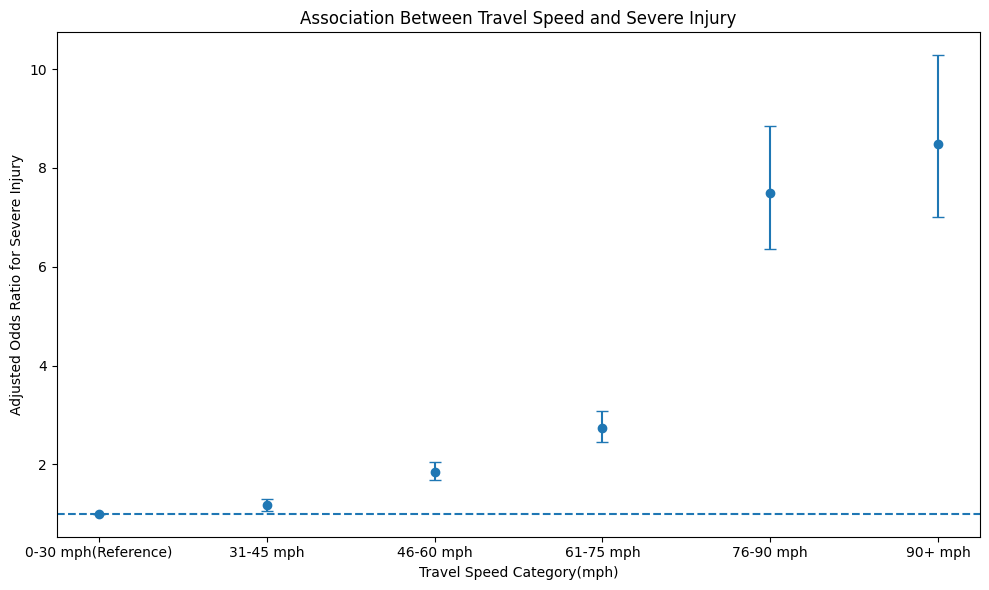

In [112]:
from numpy._core.defchararray import lower
import matplotlib.pyplot as plt
import numpy as np

# Speed-category results from Model 2
speed_results = model2_table[model2_table['Variable'].str.contains('mph')].copy()

# Add the reference category
speed_results = pd.concat([
    pd.DataFrame({
        'Variable': ['0-30 mph(Reference)'],
        'OR': [1],
        'CI_Lower': [1],
        'CI_Upper': [1],
        'P_value': [np.nan]
    }),
    speed_results
], ignore_index=True)

# Extract labels for plotting
labels = [
    '0-30 mph(Reference)',
    '31-45 mph',
    '46-60 mph',
    '61-75 mph',
    '76-90 mph',
    '90+ mph'
]
speed_results['Label'] = labels

# Calculate error bars
lower_error = speed_results['OR'] - speed_results['CI_Lower']
upper_error = speed_results['CI_Upper'] - speed_results['OR']

# Plot
plt.figure(figsize=(10, 6))
plt.errorbar(speed_results['Label'], speed_results['OR'], yerr=[lower_error, upper_error], fmt='o', capsize=4)
plt.axhline(y=1, linestyle='--') # Changed to axhline for horizontal line at OR=1
plt.xlabel('Travel Speed Category(mph)') # Swapped labels for better representation
plt.ylabel('Adjusted Odds Ratio for Severe Injury')
plt.title('Association Between Travel Speed and Severe Injury')
plt.tight_layout()
plt.show()

In [113]:
model2_summary = model2_table[
    [
        'Variable',
        'OR',
        'CI_Lower',
        'CI_Upper',
        'P_value'
    ]
].copy()
model2_summary

,Variable,OR,CI_Lower,CI_Upper,P_value
0,Intercept,0.494,0.333,0.733,0.0005
1,Other Freeways/Expressways vs Interstate,0.960,0.823,1.120,0.6029
2,Other Principal Arterial vs Interstate,1.239,1.084,1.415,0.0016
3,Minor Arterial vs Interstate,1.350,1.169,1.558,0.0000
4,Major Collector vs Interstate,1.650,1.408,1.933,0.0000
5,Minor Collector vs Interstate,1.978,1.597,2.452,0.0000
6,Local vs Interstate,1.944,1.633,2.315,0.0000
7,Morning vs Night,0.732,0.646,0.829,0.0000
8,Afternoon vs Night,0.720,0.635,0.816,0.0000
9,Evening vs Night,0.688,0.628,0.754,0.0000


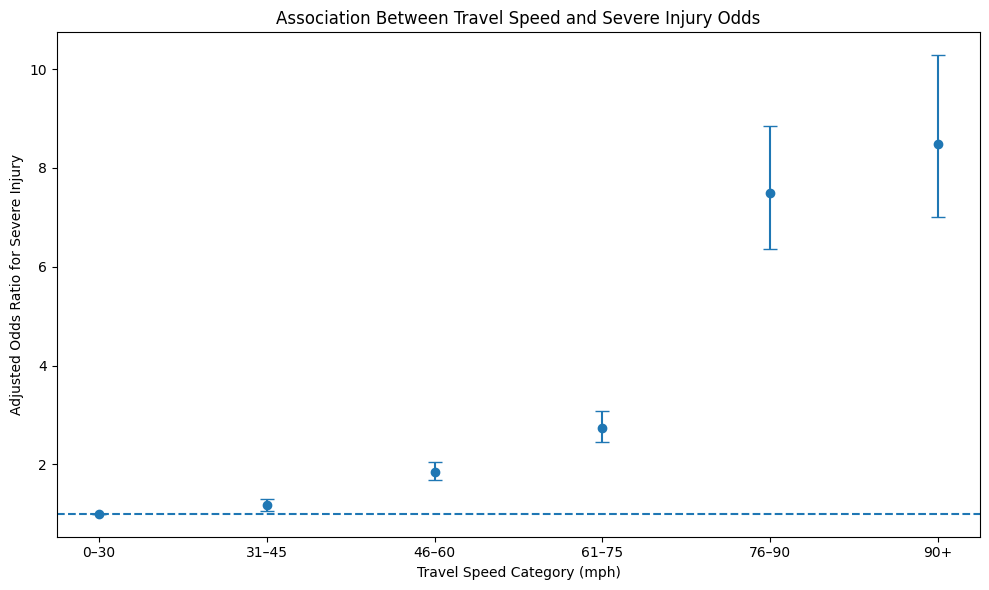

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Select only travel-speed results
speed_results = model2_table[
    model2_table['Variable'].str.contains('mph')
].copy()

# Add the reference category
reference = pd.DataFrame({
    'Variable': ['0-30 mph vs 0-30 mph'],
    'OR': [1.0],
    'CI_Lower': [1.0],
    'CI_Upper': [1.0],
    'P_value': [np.nan]
})

speed_results = pd.concat(
    [reference, speed_results],
    ignore_index=True
)

# Labels for X-axis
speed_results['Speed'] = [
    '0–30',
    '31–45',
    '46–60',
    '61–75',
    '76–90',
    '90+'
]

# Calculate error-bar lengths
lower_error = (
    speed_results['OR'] - speed_results['CI_Lower']
)

upper_error = (
    speed_results['CI_Upper'] - speed_results['OR']
)

# Create vertical graph
plt.figure(figsize=(10, 6))

plt.errorbar(
    speed_results['Speed'],
    speed_results['OR'],
    yerr=[lower_error, upper_error],
    fmt='o',
    capsize=5
)

# Reference line at OR = 1
plt.axhline(
    y=1,
    linestyle='--'
)

plt.xlabel('Travel Speed Category (mph)')
plt.ylabel('Adjusted Odds Ratio for Severe Injury')

plt.title(
    'Association Between Travel Speed and Severe Injury Odds'
)

plt.tight_layout()
plt.show()

In [ ]:
# Recreate TIME_period from HOUR

analysis_clean['TIME_period'] = pd.cut(
    analysis_clean['HOUR'].replace(99, np.nan),
    bins=[-1, 5, 11, 17, 23],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
)

print("TIME_period value counts:")
print(analysis_clean['TIME_period'].value_counts(dropna=False))

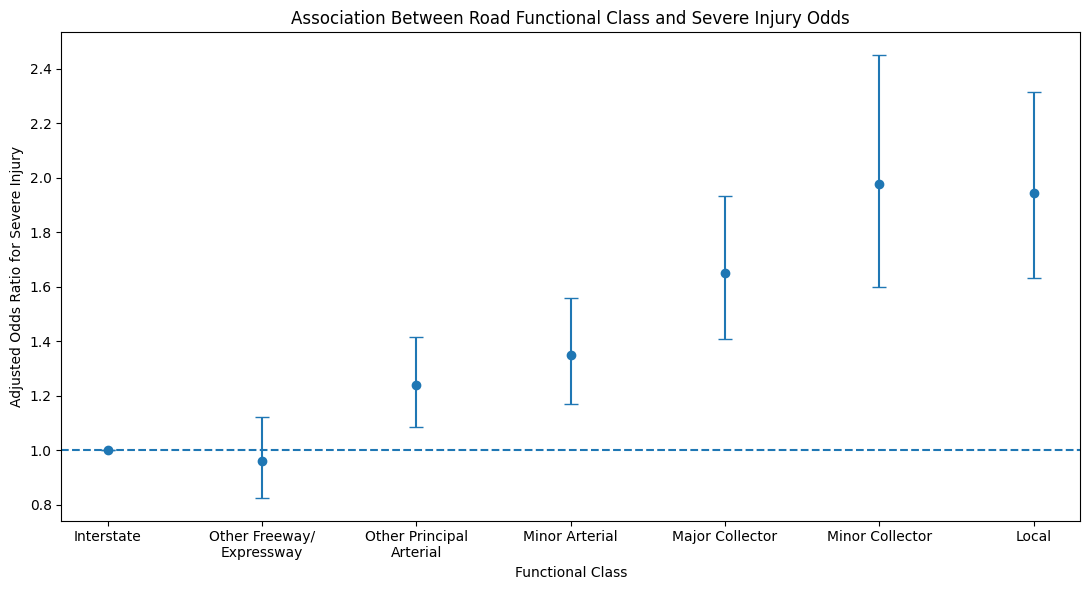

In [115]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Select functional-class results
functional_results = model2_table[
    model2_table['Variable'].str.contains(
        'vs Interstate',
        na=False
    )
].copy()

# Keep only functional-class rows
functional_results = functional_results[
    ~functional_results['Variable'].str.contains(
        'mph',
        na=False
    )
].copy()

# Add the reference category
reference = pd.DataFrame({
    'Variable': ['Interstate vs Interstate'],
    'OR': [1.0],
    'CI_Lower': [1.0],
    'CI_Upper': [1.0],
    'P_value': [np.nan]
})

functional_results = pd.concat(
    [reference, functional_results],
    ignore_index=True
)

# Short labels for the X-axis
functional_results['Functional Class'] = [
    'Interstate',
    'Other Freeway/\nExpressway',
    'Other Principal\nArterial',
    'Minor Arterial',
    'Major Collector',
    'Minor Collector',
    'Local'
]

# Calculate error-bar lengths
lower_error = (
    functional_results['OR']
    - functional_results['CI_Lower']
)

upper_error = (
    functional_results['CI_Upper']
    - functional_results['OR']
)

# Create graph
plt.figure(figsize=(11, 6))

plt.errorbar(
    functional_results['Functional Class'],
    functional_results['OR'],
    yerr=[lower_error, upper_error],
    fmt='o',
    capsize=5
)

# Reference line
plt.axhline(
    y=1,
    linestyle='--'
)

plt.xlabel('Functional Class')
plt.ylabel('Adjusted Odds Ratio for Severe Injury')

plt.title(
    'Association Between Road Functional Class and Severe Injury Odds'
)

plt.tight_layout()
plt.show()

In [37]:
# ===========================================
# STEP 12: Check Extracted FARS Files
# ===========================================
print(os.listdir('fars2023'))

['FARS2023NationalCSV']


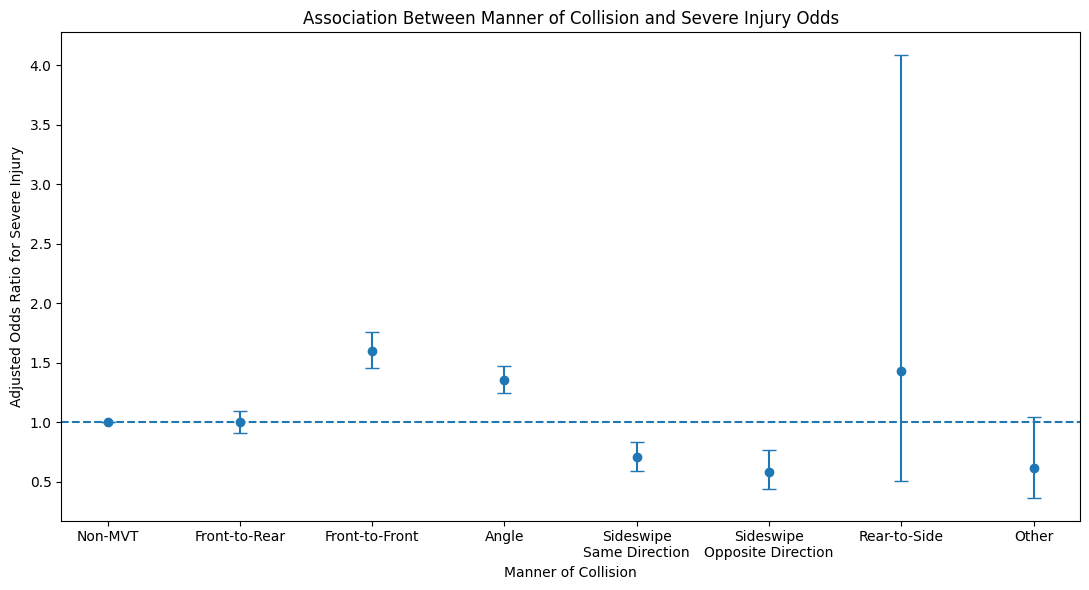

In [116]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Select manner-of-collision results
collision_results = model2_table[
    model2_table['Variable'].str.contains(
        'vs Non-MVT Collision',
        na=False
    )
].copy()

# Add the reference category
reference = pd.DataFrame({
    'Variable': ['Non-MVT Collision'],
    'OR': [1.0],
    'CI_Lower': [1.0],
    'CI_Upper': [1.0],
    'P_value': [np.nan]
})

collision_results = pd.concat(
    [reference, collision_results],
    ignore_index=True
)

# Short labels for the X-axis
collision_results['Collision Type'] = [
    'Non-MVT',
    'Front-to-Rear',
    'Front-to-Front',
    'Angle',
    'Sideswipe\nSame Direction',
    'Sideswipe\nOpposite Direction',
    'Rear-to-Side',
    'Other'
]

# Calculate error-bar lengths
lower_error = (
    collision_results['OR']
    - collision_results['CI_Lower']
)

upper_error = (
    collision_results['CI_Upper']
    - collision_results['OR']
)

# Create graph
plt.figure(figsize=(11, 6))

plt.errorbar(
    collision_results['Collision Type'],
    collision_results['OR'],
    yerr=[lower_error, upper_error],
    fmt='o',
    capsize=5
)

# Reference line at OR = 1
plt.axhline(
    y=1,
    linestyle='--'
)

plt.xlabel('Manner of Collision')
plt.ylabel('Adjusted Odds Ratio for Severe Injury')

plt.title(
    'Association Between Manner of Collision and Severe Injury Odds'
)

plt.tight_layout()
plt.show()


In [38]:
print(os.listdir('fars2023/FARS2023NationalCSV'))

['accident.csv', 'drugs.csv', 'driverrf.csv', 'safetyeq.csv', 'drimpair.csv', 'cevent.csv', 'distract.csv', 'pbtype.csv', 'vision.csv', 'factor.csv', 'nmcrash.csv', 'MIPER.CSV', 'vpictrailerdecode.csv', 'pvehiclesf.csv', 'maneuver.csv', 'damage.csv', 'crashrf.csv', 'weather.csv', 'race.csv', 'person.csv', 'vpicdecode.csv', 'nmdistract.csv', 'vehicle.csv', 'MIDRVACC.CSV', 'parkwork.csv', 'MIACC.CSV', 'nmimpair.csv', 'vevent.csv', 'violatn.csv', 'vehiclesf.csv', 'personrf.csv', 'vsoe.csv', 'nmprior.csv']


In [117]:
comparison = pd.DataFrame({
    'Model': [
        'Model 1: Speed-Related',
        'Model 2: Travel Speed'
    ],
    'Observations': [
        len(model1_final_data),
        len(model2_data)
    ],
    'Pseudo_R2': [
        model1_final.prsquared,
        model2.prsquared
    ]
})

comparison

,Model,Observations,Pseudo_R2
0,Model 1: Speed-Related,70705,0.082460
1,Model 2: Travel Speed,28437,0.091427


In [118]:
speed_comparison = pd.DataFrame({
    'Speed Measure': [
        'Speed-related crash',
        '31–45 mph',
        '46–60 mph',
        '61–75 mph',
        '76–90 mph',
        '90+ mph'
    ],
    'Adjusted OR': [
        3.737,
        1.171,
        1.851,
        2.745,
        7.496,
        8.485
    ]
})

speed_comparison

,Speed Measure,Adjusted OR
0,Speed-related crash,3.737
1,31–45 mph,1.171
2,46–60 mph,1.851
3,61–75 mph,2.745
4,76–90 mph,7.496
5,90+ mph,8.485


In [119]:
missing_speed = analysis_clean['TRAVEL_SPEED_MPH'].isna().sum()
total_records = len(analysis_clean)

print("Total analysis records:", total_records)
print("Missing travel speed:", missing_speed)
print("Available travel speed:", total_records - missing_speed)
print("Missing percentage:", round(missing_speed / total_records * 100, 2))

Total analysis records: 81269
Missing travel speed: 49295
Available travel speed: 31974
Missing percentage: 60.66


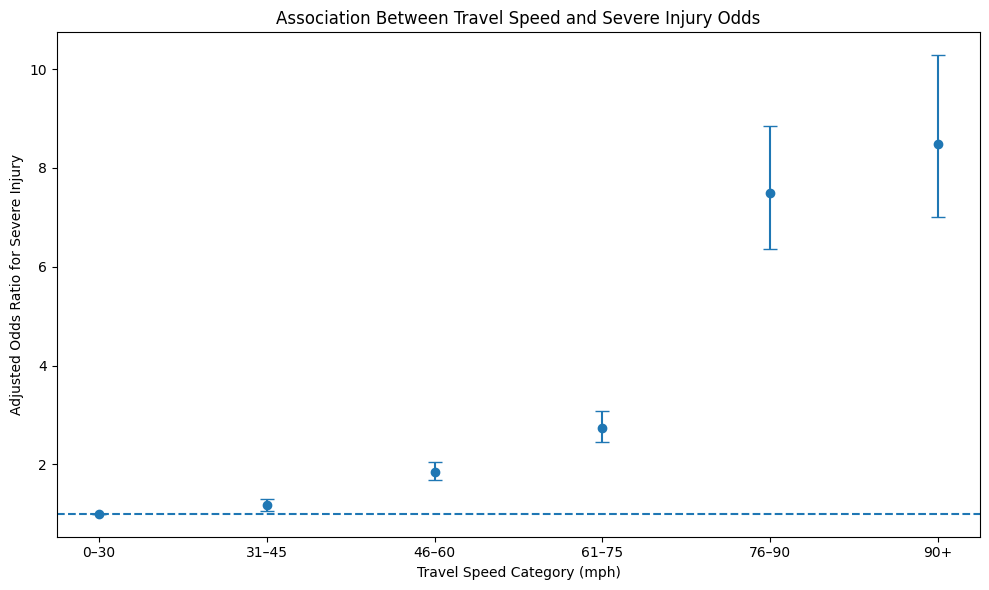

In [120]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

speed_results = model2_table[
    model2_table['Variable'].str.contains('mph', na=False)
].copy()

reference = pd.DataFrame({
    'Variable': ['0-30 mph'],
    'OR': [1.0],
    'CI_Lower': [1.0],
    'CI_Upper': [1.0]
})

speed_results = pd.concat(
    [reference, speed_results[['Variable', 'OR', 'CI_Lower', 'CI_Upper']]],
    ignore_index=True
)

speed_results['Speed'] = [
    '0–30',
    '31–45',
    '46–60',
    '61–75',
    '76–90',
    '90+'
]

lower_error = speed_results['OR'] - speed_results['CI_Lower']
upper_error = speed_results['CI_Upper'] - speed_results['OR']

plt.figure(figsize=(10, 6))

plt.errorbar(
    speed_results['Speed'],
    speed_results['OR'],
    yerr=[lower_error, upper_error],
    fmt='o',
    capsize=5
)

plt.axhline(y=1, linestyle='--')

plt.xlabel('Travel Speed Category (mph)')
plt.ylabel('Adjusted Odds Ratio for Severe Injury')
plt.title('Association Between Travel Speed and Severe Injury Odds')

plt.tight_layout()

plt.savefig(
    'travel_speed_odds_ratio.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


In [23]:
# ===========================================
# STEP 7: Inspect Intersection Variable
# ===========================================

print("TYP_INT value counts:")
print(analysis_clean['TYP_INT'].value_counts(dropna=False).sort_Index())

TYP_INT value counts:


KeyError: 'TYP_INT'

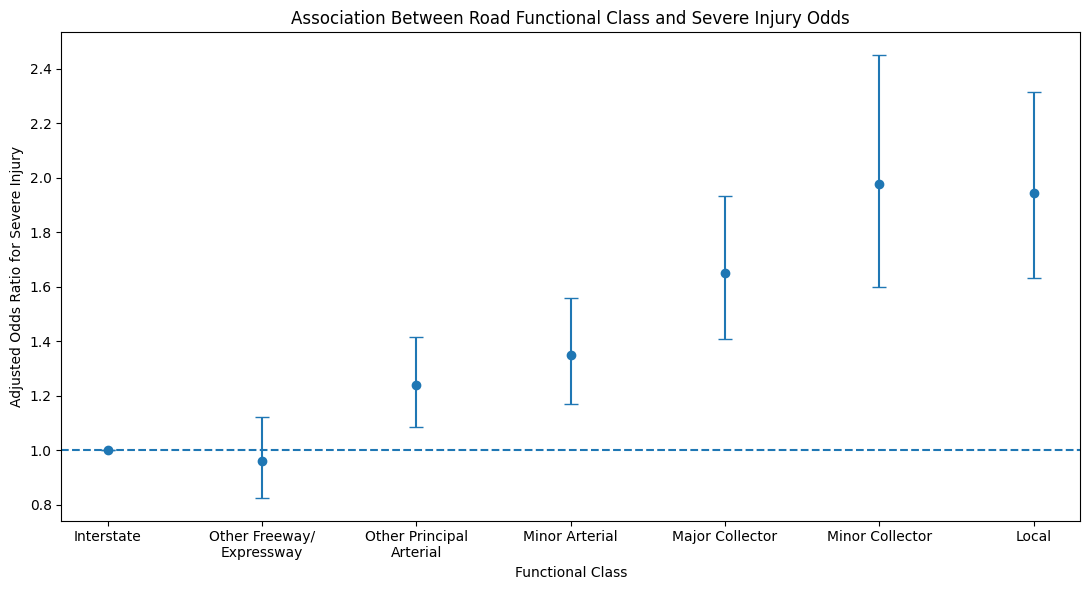

In [121]:
functional_results = model2_table[
    model2_table['Variable'].str.contains(
        'vs Interstate',
        na=False
    )
].copy()

reference = pd.DataFrame({
    'Variable': ['Interstate'],
    'OR': [1.0],
    'CI_Lower': [1.0],
    'CI_Upper': [1.0]
})

functional_results = pd.concat(
    [
        reference,
        functional_results[['Variable', 'OR', 'CI_Lower', 'CI_Upper']]
    ],
    ignore_index=True
)

functional_results['Functional Class'] = [
    'Interstate',
    'Other Freeway/\nExpressway',
    'Other Principal\nArterial',
    'Minor Arterial',
    'Major Collector',
    'Minor Collector',
    'Local'
]

lower_error = (
    functional_results['OR']
    - functional_results['CI_Lower']
)

upper_error = (
    functional_results['CI_Upper']
    - functional_results['OR']
)

plt.figure(figsize=(11, 6))

plt.errorbar(
    functional_results['Functional Class'],
    functional_results['OR'],
    yerr=[lower_error, upper_error],
    fmt='o',
    capsize=5
)

plt.axhline(y=1, linestyle='--')

plt.xlabel('Functional Class')
plt.ylabel('Adjusted Odds Ratio for Severe Injury')
plt.title(
    'Association Between Road Functional Class and Severe Injury Odds'
)

plt.tight_layout()

plt.savefig(
    'functional_class_odds_ratio.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [17]:
# Clean up and verify our derived variables

# Remove old/raw columns that we don't need in the analysis dataset
# RUR_URB and LGT_COND were transformed in place and are now the derived variables.
# WEATHER is the raw column from which ADVERSE_WEATHER was derived, so it can be dropped.
analysis_clean = analysis_clean.drop(
    columns=['WEATHER'],
    errors = 'ignore'
)

print("Analysis shape", analysis_clean.shape)
print("\nUrban/Rural (0 = Rural, 1 = Urban):")
print(analysis_clean['RUR_URB'].value_counts(dropna=False))
print("\nLighting (0 = Daylight, 1 = Dark):")
print(analysis_clean['LGT_COND'].value_counts(dropna=False))
print("\nAdverse Weather (0 = Clear, 1 = Adverse):")
print(analysis_clean['ADVERSE_WEATHER'].value_counts(dropna=False))

Analysis shape (81269, 127)

Urban/Rural (0 = Rural, 1 = Urban):


KeyError: 'RUR_URB'

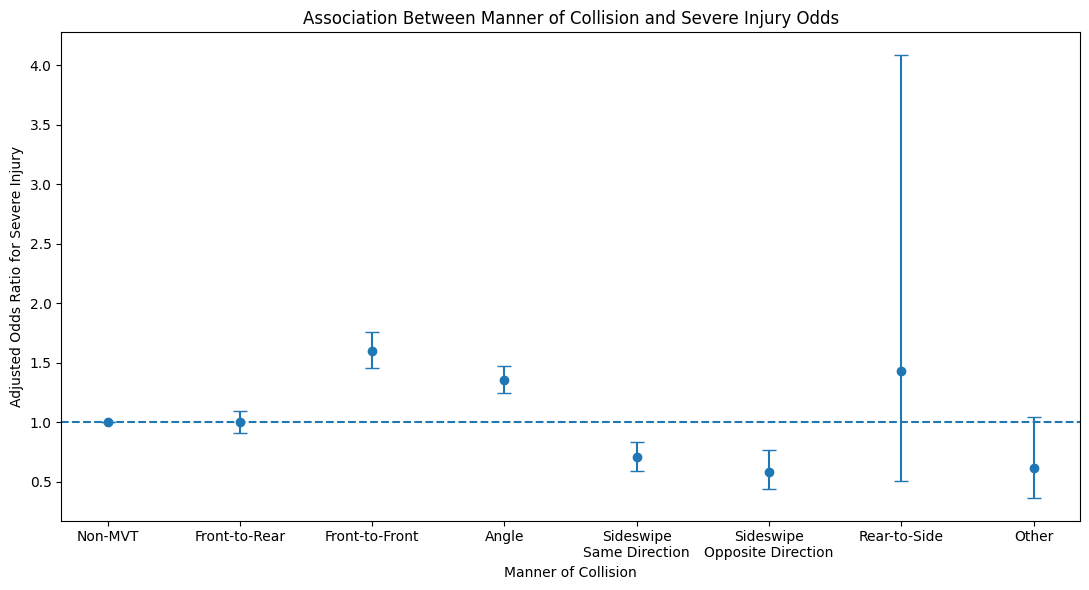

In [122]:
collision_results = model2_table[
    model2_table['Variable'].str.contains(
        'vs Non-MVT Collision',
        na=False
    )
].copy()

reference = pd.DataFrame({
    'Variable': ['Non-MVT Collision'],
    'OR': [1.0],
    'CI_Lower': [1.0],
    'CI_Upper': [1.0]
})

collision_results = pd.concat(
    [
        reference,
        collision_results[['Variable', 'OR', 'CI_Lower', 'CI_Upper']]
    ],
    ignore_index=True
)

collision_results['Collision Type'] = [
    'Non-MVT',
    'Front-to-Rear',
    'Front-to-Front',
    'Angle',
    'Sideswipe\nSame Direction',
    'Sideswipe\nOpposite Direction',
    'Rear-to-Side',
    'Other'
]

lower_error = (
    collision_results['OR']
    - collision_results['CI_Lower']
)

upper_error = (
    collision_results['CI_Upper']
    - collision_results['OR']
)

plt.figure(figsize=(11, 6))

plt.errorbar(
    collision_results['Collision Type'],
    collision_results['OR'],
    yerr=[lower_error, upper_error],
    fmt='o',
    capsize=5
)

plt.axhline(y=1, linestyle='--')

plt.xlabel('Manner of Collision')
plt.ylabel('Adjusted Odds Ratio for Severe Injury')
plt.title(
    'Association Between Manner of Collision and Severe Injury Odds'
)

plt.tight_layout()

plt.savefig(
    'manner_collision_odds_ratio.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

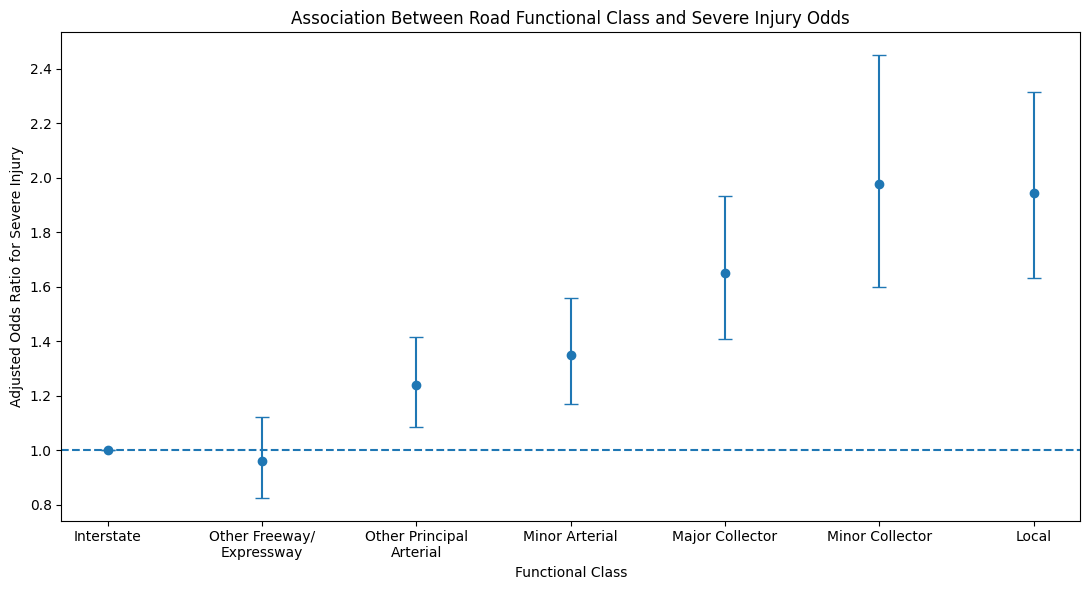

In [123]:
functional_results = model2_table[
    model2_table['Variable'].str.contains(
        'vs Interstate',
        na=False
    )
].copy()

reference = pd.DataFrame({
    'Variable': ['Interstate'],
    'OR': [1.0],
    'CI_Lower': [1.0],
    'CI_Upper': [1.0]
})

functional_results = pd.concat(
    [
        reference,
        functional_results[['Variable', 'OR', 'CI_Lower', 'CI_Upper']]
    ],
    ignore_index=True
)

functional_results['Functional Class'] = [
    'Interstate',
    'Other Freeway/\nExpressway',
    'Other Principal\nArterial',
    'Minor Arterial',
    'Major Collector',
    'Minor Collector',
    'Local'
]

lower_error = (
    functional_results['OR']
    - functional_results['CI_Lower']
)

upper_error = (
    functional_results['CI_Upper']
    - functional_results['OR']
)

plt.figure(figsize=(11, 6))

plt.errorbar(
    functional_results['Functional Class'],
    functional_results['OR'],
    yerr=[lower_error, upper_error],
    fmt='o',
    capsize=5
)

plt.axhline(y=1, linestyle='--')

plt.xlabel('Functional Class')
plt.ylabel('Adjusted Odds Ratio for Severe Injury')
plt.title(
    'Association Between Road Functional Class and Severe Injury Odds'
)

plt.tight_layout()

plt.savefig(
    'functional_class_odds_ratio.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

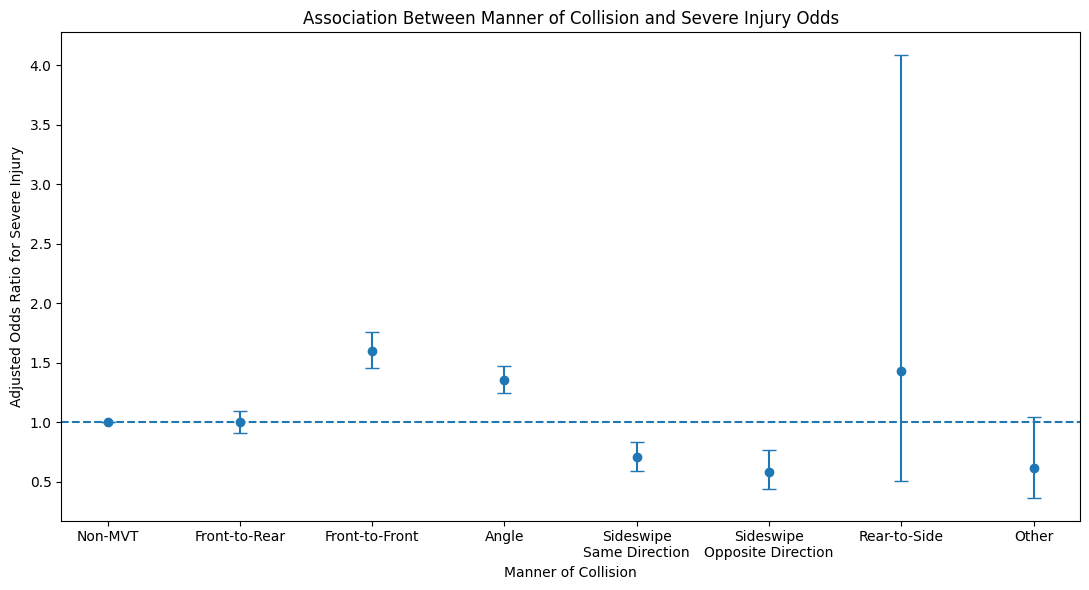

In [124]:
collision_results = model2_table[
    model2_table['Variable'].str.contains(
        'vs Non-MVT Collision',
        na=False
    )
].copy()

reference = pd.DataFrame({
    'Variable': ['Non-MVT Collision'],
    'OR': [1.0],
    'CI_Lower': [1.0],
    'CI_Upper': [1.0]
})

collision_results = pd.concat(
    [
        reference,
        collision_results[['Variable', 'OR', 'CI_Lower', 'CI_Upper']]
    ],
    ignore_index=True
)

collision_results['Collision Type'] = [
    'Non-MVT',
    'Front-to-Rear',
    'Front-to-Front',
    'Angle',
    'Sideswipe\nSame Direction',
    'Sideswipe\nOpposite Direction',
    'Rear-to-Side',
    'Other'
]

lower_error = (
    collision_results['OR']
    - collision_results['CI_Lower']
)

upper_error = (
    collision_results['CI_Upper']
    - collision_results['OR']
)

plt.figure(figsize=(11, 6))

plt.errorbar(
    collision_results['Collision Type'],
    collision_results['OR'],
    yerr=[lower_error, upper_error],
    fmt='o',
    capsize=5
)

plt.axhline(y=1, linestyle='--')

plt.xlabel('Manner of Collision')
plt.ylabel('Adjusted Odds Ratio for Severe Injury')

plt.title(
    'Association Between Manner of Collision and Severe Injury Odds'
)

plt.tight_layout()

plt.savefig(
    'manner_collision_odds_ratio.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()